# Hospital Readmission Prediction Project: Predictive Modeling


### **Author:**  Ari M.


### **Purpose & Goal:**
### The goal of this project is to see whether patient readmissions within 30 days can be predicted using hospital encounter data.
### I wanted to compare a few different modeling approaches and also see which patient patterns kept showing up across models.


### **Dataset used:** diabetic_features.csv

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import kagglehub

# Download latest version
feature_path = kagglehub.dataset_download("datascienceam/diabetic-features-csv")

print("Path to dataset files:", feature_path)

Path to dataset files: /kaggle/input/datasets/datascienceam/diabetic-features-csv


In [3]:
# On local system
# df = pd.read_csv("../data/processed/diabetic_features.csv")

# On Kaggle
import os

feature_file_path = os.path.join(feature_path, "diabetic_features.csv")
df = pd.read_csv(feature_file_path, low_memory=False)

df.head()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,glyburide-metformin_No,glyburide-metformin_Steady,glyburide-metformin_Up,glipizide-metformin_Steady,glimepiride-pioglitazone_Steady,metformin-rosiglitazone_Steady,metformin-pioglitazone_Steady,change_No,diabetesMed_Yes,readmitted_30
0,6,25,1,1,41,0,1,0,0,0,...,True,False,False,False,False,False,False,True,False,0
1,1,1,7,3,59,0,18,0,0,0,...,True,False,False,False,False,False,False,False,True,0
2,1,1,7,2,11,5,13,2,0,1,...,True,False,False,False,False,False,False,True,True,0
3,1,1,7,2,44,1,16,0,0,0,...,True,False,False,False,False,False,False,False,True,0
4,1,1,7,1,51,0,8,0,0,0,...,True,False,False,False,False,False,False,False,True,0


## Target Variable

For the target variable, I’m using:

- `readmitted_30`
    - `0` = not readmitted
    - `1` = readmitted within 30 days

In [4]:
target = "readmitted_30"

y = df[target]
X = df.drop(columns=[target])

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (101766, 2417)
Shape of y: (101766,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (81412, 2417)
Test shape: (20354, 2417)


## Train/Test Split

I used stratification because the positive class is relatively small (~11%).

Without stratifying, it would be easy to end up with slightly different class distributions between train and test sets.

## Feature Scaling

For Logistic Regression, I standardized the numeric columns before training.

I left the one-hot encoded columns alone since scaling those usually doesn’t add much value.

In [6]:
from sklearn.preprocessing import StandardScaler

numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

## Baseline Model 

I usually like starting with Logistic Regression first before jumping into more complex models.

It gives a decent baseline and is easier to interpret compared to ensemble methods.

In [7]:
baseline_model = LogisticRegression(
    max_iter=2000,
    class_weight="balanced"
)

baseline_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=2000)

In [8]:
y_pred = baseline_model.predict(X_test_scaled)
y_prob = baseline_model.predict_proba(X_test_scaled)[:, 1]

## Model Evaluation

Because the dataset is imbalanced, accuracy alone would be misleading here.

I paid more attention to:
- recall
- precision
- ROC-AUC

Recall matters a lot in this problem since missing high-risk patients is probably worse than creating extra follow-up work.

In [9]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.66      0.77     18083
           1       0.17      0.55      0.26      2271

    accuracy                           0.64     20354
   macro avg       0.54      0.60      0.51     20354
weighted avg       0.84      0.64      0.71     20354



In [10]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.6440849477943003


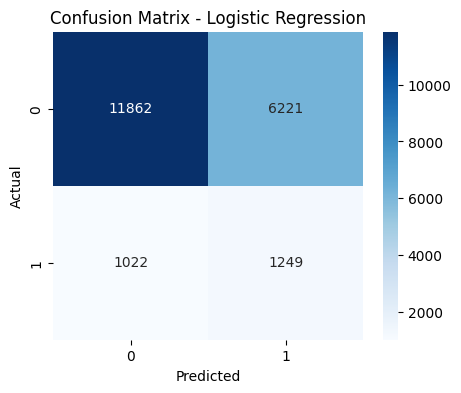

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Note on Reproducibility

One thing I noticed while rerunning this notebook across environments (local vs Kaggle) is that the confusion matrix values can shift slightly even when using the same random_state.

The differences are very small and don’t meaningfully change the interpretation of model performance, but it’s a good reminder that small variations can happen depending on execution environment, data loading behavior, or underlying library implementations.

To keep results as consistent as possible, I used:

random_state=42 for the train/test split
stratified sampling to preserve the class distribution (~11%)

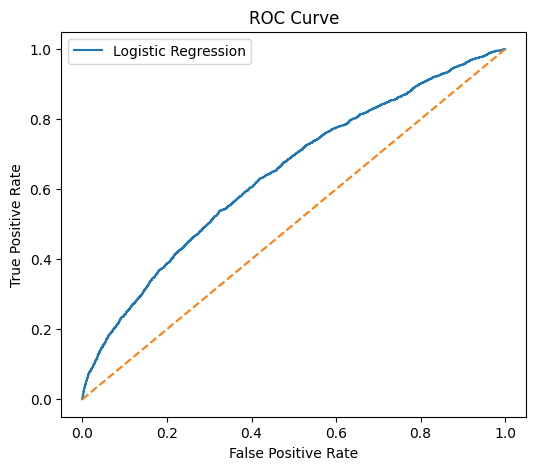

In [12]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0,1], [0,1], linestyle="--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.show()

## Initial Interpretation

The model is finding some signal, but the separation between the two classes still looks pretty weak.

One thing that stood out is that recall is much better than I expected from a basic Logistic Regression model.

I also noticed that utilization-related variables kept appearing important throughout the project.

Features tied to prior hospital usage seem much more predictive than demographic variables.

## Tree-Based Model (Random Forest)

Next I tried a Random Forest model to see whether a tree-based approach could capture patterns that Logistic Regression missed.

In [13]:
from sklearn.ensemble import RandomForestClassifier

In [14]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=-1, random_state=42)

In [15]:
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [16]:
print("Random Forest Classification Report")
print(classification_report(y_test, y_pred_rf))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.70      0.01      0.01      2271

    accuracy                           0.89     20354
   macro avg       0.79      0.50      0.48     20354
weighted avg       0.87      0.89      0.84     20354



In [17]:
rf_auc = roc_auc_score(y_test, y_prob_rf)
print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.648597811846266


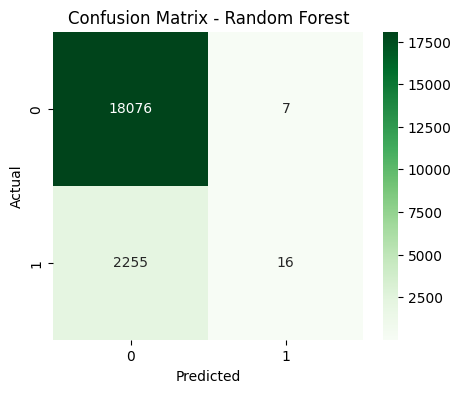

In [18]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
feature_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="importance",
    ascending=False
)

feature_importance.head(10)

,feature,importance
4,num_lab_procedures,0.049286
6,num_medications,0.045686
9,number_inpatient,0.038864
3,time_in_hospital,0.036203
1,discharge_disposition_id,0.029452
10,number_diagnoses,0.026483
5,num_procedures,0.025780
0,admission_type_id,0.019071
2,admission_source_id,0.017064
15,gender_Male,0.014026


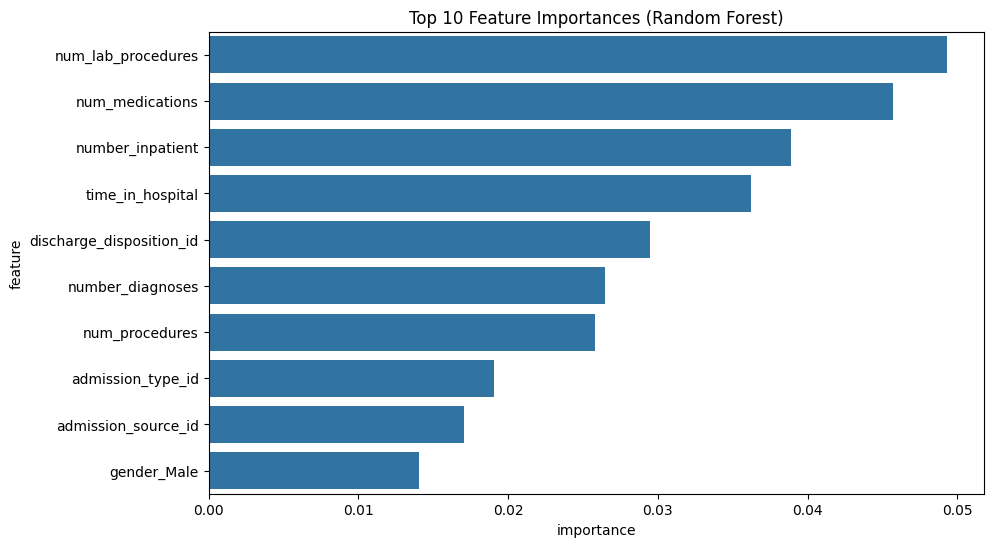

In [20]:
plt.figure(figsize=(10,6))

top_features = feature_importance.head(10)

sns.barplot(
    x="importance",
    y="feature",
    data=top_features
)

plt.title("Top 10 Feature Importances (Random Forest)")
plt.show()

## Random Forest Insights

Honestly, I expected Random Forest to perform better than this.

The accuracy looked high at first, but after checking recall for class 1, it became obvious the model was mostly predicting the majority class.

### Feature Importance:

The same variables kept showing up again:

- inpatient visits
- medications
- time in hospital

That consistency made me feel more confident the models were at least detecting a real pattern in the data.

## Model Comparison

What surprised me here was that Logistic Regression still performed best for recall even after trying more complex models.

## Threshold Tuning

In this type of problem, missing a high-risk patient is probably more costly than flagging someone unnecessarily.

In [21]:
# Trying a lower threshold
threshold = 0.30

y_pred_rf_adjusted = (y_prob_rf >= threshold).astype(int)

In [22]:
print(f"Random Forest (Threshold = {threshold})")
print(classification_report(y_test, y_pred_rf_adjusted))

Random Forest (Threshold = 0.3)
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     18083
           1       0.44      0.05      0.09      2271

    accuracy                           0.89     20354
   macro avg       0.67      0.52      0.51     20354
weighted avg       0.84      0.89      0.84     20354



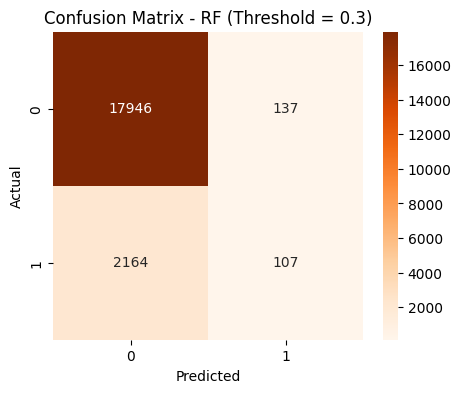

In [23]:
cm_rf_adj = confusion_matrix(y_test, y_pred_rf_adjusted)

plt.figure(figsize=(5,4))
sns.heatmap(cm_rf_adj, annot=True, fmt="d", cmap="Oranges")

plt.title(f"Confusion Matrix - RF (Threshold = {threshold})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## XGBoost Model 

I also wanted to test XGBoost since it tends to perform well on structured tabular datasets like this one.

In [24]:
from xgboost import XGBClassifier

In [25]:
# Cleaning column names for XGBoost compatibility
X_train_clean = X_train.copy()
X_test_clean = X_test.copy()

X_train_clean.columns = (
    X_train_clean.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
    .str.replace(">", "", regex=False)
)

X_test_clean.columns = (
    X_test_clean.columns
    .str.replace("[", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("<", "", regex=False)
    .str.replace(">", "", regex=False)
)

In [26]:
# Ensuring same column order between train and test
X_test_clean = X_test_clean[X_train_clean.columns]

In [27]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_clean, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None,
              num_parallel_tree=None, ...)

In [28]:
y_pred_xgb = xgb_model.predict(X_test_clean)
y_prob_xgb = xgb_model.predict_proba(X_test_clean)[:, 1]

In [29]:
print("XGBoost Classification Report")
print(classification_report(y_test, y_pred_xgb))

XGBoost Classification Report
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.61      0.01      0.03      2271

    accuracy                           0.89     20354
   macro avg       0.75      0.51      0.48     20354
weighted avg       0.86      0.89      0.84     20354



In [30]:
xgb_auc = roc_auc_score(y_test, y_prob_xgb)
print("XGBoost ROC-AUC:", xgb_auc)

XGBoost ROC-AUC: 0.6870723779602996


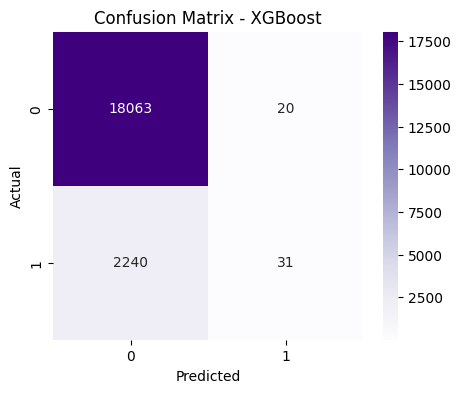

In [31]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Purples")

plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
feature_importance_xgb = pd.DataFrame({
    "feature": X_train_clean.columns,
    "importance": xgb_model.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by="importance",
    ascending=False
)

feature_importance_xgb.head(10)

,feature,importance
9,number_inpatient,0.018711
820,diag_1_V57,0.010564
1,discharge_disposition_id,0.008463
821,diag_1_V58,0.007973
684,diag_1_820,0.006482
1075,diag_2_413,0.006125
8,number_emergency,0.006102
394,diag_1_434,0.005583
275,diag_1_296,0.004923
1682,diag_3_250.6,0.004884


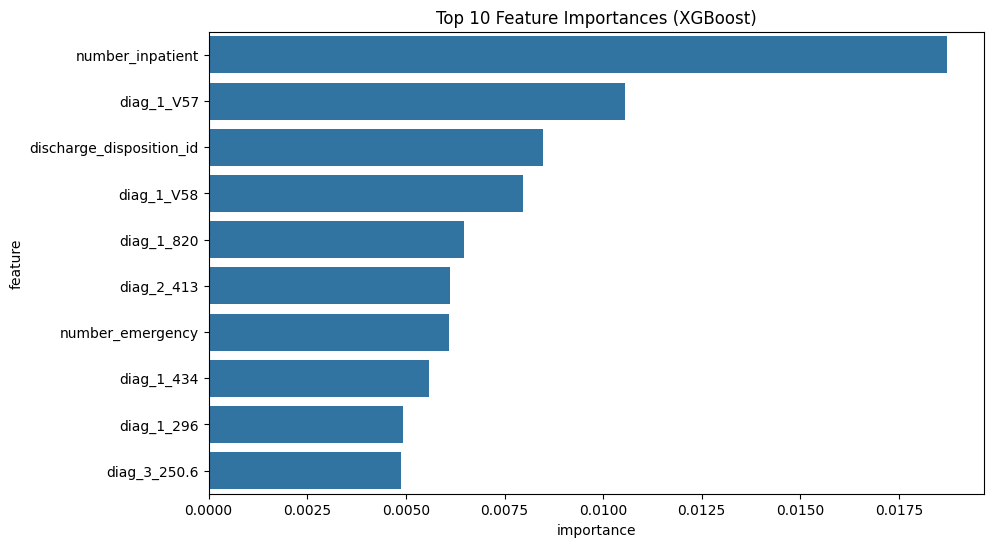

In [33]:
plt.figure(figsize=(10,6))

top_features = feature_importance_xgb.head(10)

sns.barplot(
    x="importance",
    y="feature",
    data=top_features
)

plt.title("Top 10 Feature Importances (XGBoost)")
plt.show()

## XGBoost Insights

At this point, it seemed like the models were learning more from overall healthcare usage patterns than from specific diagnoses alone.

One thing I noticed while rerunning the notebook across environments (local vs Kaggle) is that XGBoost produced slightly different confusion matrix values even with the same random seed.

The differences were very small and did not materially change model performance, but it was a useful reminder that some ensemble methods are not always perfectly reproducible across systems.

## Precision-Recall Curve & Threshold Optimization
Rather than picking a threshold manually, I used the precision-recall curve to see where the tradeoff looked most reasonable.

In [34]:
from sklearn.metrics import precision_recall_curve

In [35]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_xgb)

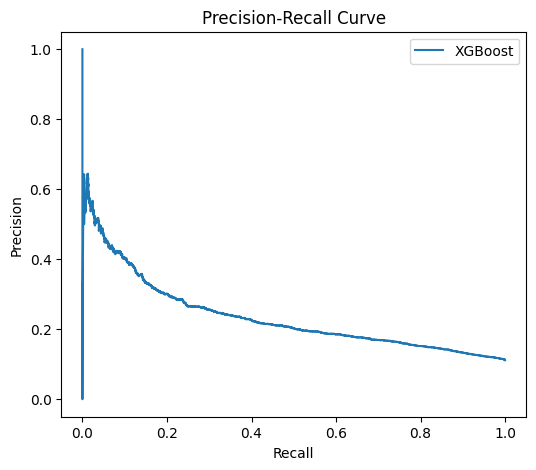

In [36]:
plt.figure(figsize=(6,5))

plt.plot(recall, precision, label="XGBoost")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()

plt.show()

In [37]:
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print("Best Threshold:", best_threshold)
print("Best F1 Score:", f1_scores[best_idx])

Best Threshold: 0.13648194
Best F1 Score: 0.29173463412213246


In [38]:
y_pred_xgb_opt = (y_prob_xgb >= best_threshold).astype(int)

In [39]:
print("XGBoost (Optimized Threshold)")
print(classification_report(y_test, y_pred_xgb_opt))

XGBoost (Optimized Threshold)
              precision    recall  f1-score   support

           0       0.92      0.78      0.84     18083
           1       0.21      0.47      0.29      2271

    accuracy                           0.74     20354
   macro avg       0.57      0.63      0.57     20354
weighted avg       0.84      0.74      0.78     20354



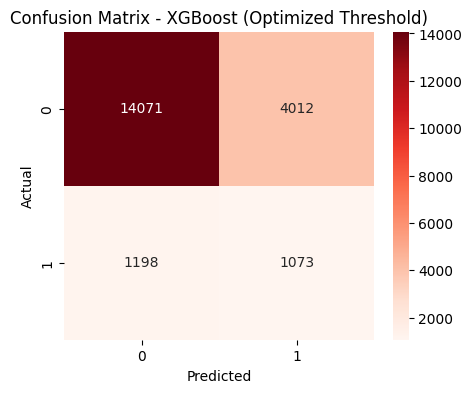

In [40]:
cm_xgb_opt = confusion_matrix(y_test, y_pred_xgb_opt)

plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb_opt, annot=True, fmt="d", cmap="Reds")

plt.title("Confusion Matrix - XGBoost (Optimized Threshold)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## Threshold Optimization Insight

After threshold optimization, I noticed slightly larger differences between local and Kaggle prediction outputs compared to the default threshold model.

My guess is that many predicted probabilities were clustered near the threshold cutoff, so very small probability differences caused some predictions to flip classes.

## Healthcare-Related Observations

One pattern stayed pretty consistent across all the models:

Patients with heavier prior healthcare usage were more likely to be readmitted.

Things like:
- previous inpatient visits
- number of medications
- longer hospital stays

kept showing up as important features.

At the same time, separating readmitted vs non-readmitted patients was still difficult even with stronger models like XGBoost.

A lot of patient profiles overlap, which probably makes this a difficult prediction problem in general.

## Possible Next Steps / Practical Use

I don’t think these models are strong enough to be used by themselves in a real hospital setting, but they could still help identify patients who may need extra follow-up attention.

Some ideas that seem reasonable based on the results:
- prioritize follow-up for patients with high prior utilization
- review discharge planning for higher-risk patients
- use model scores as a support tool rather than a final decision-maker

I also think additional variables could help a lot here, especially things related to social support, follow-up access, or socioeconomic factors.

## Reflection

I thought XGBoost would clearly outperform everything else, but the improvement was smaller than I expected.

Even though XGBoost achieved the best ROC-AUC overall, Logistic Regression ended up being the most useful model for this project because recall mattered more than raw accuracy.

For this problem, I’d rather identify more potentially high-risk patients even if it means accepting more false positives.

## Turning the Model into a Clinical Risk Scoring System

At this point I didn’t really want to stop at just “model performance metrics” anymore. In a real hospital setting, nobody is looking at ROC-AUC on a slide — they care about who should we actually follow up with today.

So instead of only outputting a 0/1 prediction, I switched to using predicted probabilities as a simple risk score.

In [41]:
risk_probs = baseline_model.predict_proba(X_test_scaled)[:, 1]

### Building a simple risk view of patients

I wrapped the probabilities into a dataframe so it’s easier to think about in a “patient list” format rather than a modeling output.

In [42]:
risk_df = pd.DataFrame({
    "risk_score": risk_probs,
    "actual_readmission": y_test.values
})

Then I split patients into rough risk groups. These cutoffs are honestly a bit arbitrary (I tried a couple versions), but this felt like a reasonable starting point:

In [43]:
risk_df["risk_level"] = pd.cut(
    risk_df["risk_score"],
    bins=[0, 0.3, 0.6, 1.0],
    labels=["Low", "Medium", "High"]
)

### Risk Scoring System

So now instead of saying that this patient will be readmitted (1) or not (0), I can say something like:

- Low risk (< 0.3)
- Medium risk (0.3 – 0.6)
- High risk (> 0.6)

This feels more aligned with how clinical workflows actually work — more about prioritization than strict prediction.

### What the risk scores look like

I plotted the distribution just to sanity check that the model wasn’t doing anything weird (like pushing everything into one bucket).

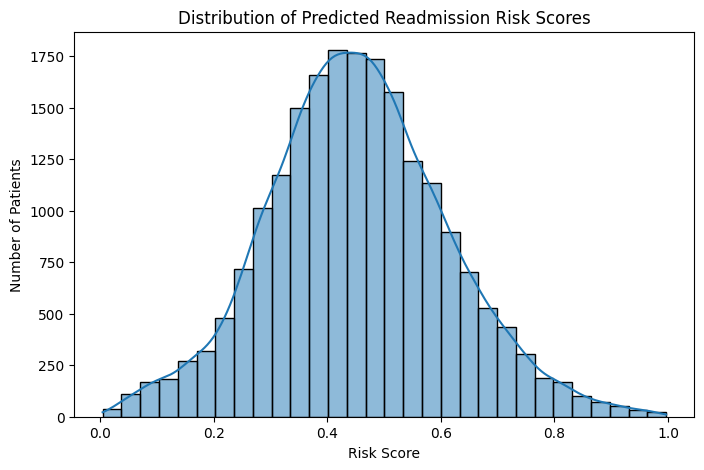

In [44]:
plt.figure(figsize=(8,5))

sns.histplot(risk_probs, bins=30, kde=True)

plt.title("Distribution of Predicted Readmission Risk Scores")
plt.xlabel("Risk Score")
plt.ylabel("Number of Patients")

plt.show()

What stood out here is that a lot of patients are kind of clustered in the middle range, which makes sense given earlier models struggled with clean separation between classes.

### Simulating a clinical decision threshold

Even though probabilities are more useful, I still tested a threshold-based cutoff just to see how it would behave operationally.

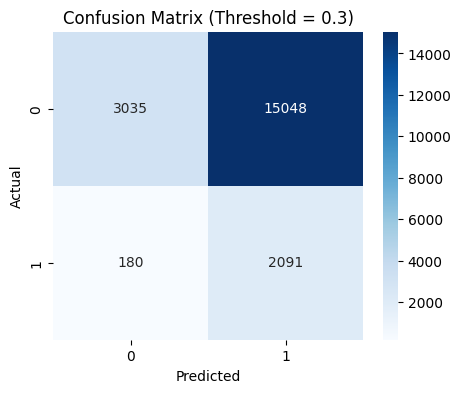

In [45]:
threshold = 0.3

y_pred_threshold = (risk_probs >= threshold).astype(int)

cm = confusion_matrix(y_test, y_pred_threshold)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title(f"Confusion Matrix (Threshold = {threshold})")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

This part kind of highlights the tradeoff again, lowering the threshold does catch more true positives, but also adds a fair number of false positives. Depending on the hospital workflow, that might still be acceptable.

### How I’m thinking about this clinically 

I am thinking this as a flagging system.

High-risk patients could be used to support things like:

- extra discharge planning attention
- follow-up scheduling earlier than usual
- medication reconciliation checks
- general “just don’t lose track of this person” list



### Exporting results for downstream use

I also saved out a simple table that could realistically be handed off to a BI tool or hospital reporting system.

In [46]:
final_output = X_test.copy()
final_output["risk_score"] = risk_probs
final_output["actual"] = y_test.values

# On local system
# final_output.to_csv("../data/processed/patient_risk_scores.csv", index=False)

# On Kaggle
import os

os.makedirs("/kaggle/working/data/processed", exist_ok=True)

final_output.to_csv("/kaggle/working/data/processed/patient_risk_scores.csv", index=False)

### Next step: dashboarding

The next thing I want to do (outside of modeling) is plug this into a Power BI dashboard.

The idea would be something like:

- overall distribution of risk scores
- list of high-risk patients (sortable / filterable)
- breakdown of key drivers (from feature importance work earlier)
- maybe some basic cohort slicing (age, admission type, etc.)